# ML-02 — Research Question and Provisional Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/whozahm3d/flyrank-ml-internship/blob/main/work/notebooks/w01_research_question.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane (or freestyle) and why

I'm choosing the freestyle direction: AI Referral Opportunity. Search visibility has traditionally meant ranking in Google, but AI tools (ChatGPT, Perplexity, AI Overviews) are increasingly a discovery channel of their own, and almost no one — including FlyRank's own product — has built tooling around it yet. The warehouse data has a genuinely rare asset: sessions_ai in fact_content_daily_performance (starter: ai_sessions_90d / ai_traffic_pct), real measured sessions where someone clicked through from an AI tool. I want to find out what, if anything, distinguishes the small set of pages that do get AI referral traffic from the vast majority that don't — content type, structure signals, freshness, position, intent — as a starting map for where AI visibility might be improved.

I know this data is sparse (30,177 AI-session rows vs. 78.8M daily rows in the warehouse), so I'm treating this as EDA and opportunity-ranking work, not classification. If it holds up, I want to push further in later weeks toward predicting future growth/recovery/momentum as a stretch goal — but Week 1's job is just to show there's something real worth chasing here.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. The question: decision, action, cost of a wrong call

Unit of analysis: a content item (one row per content_id / content_hash_id), looking at its AI-referral session activity over a defined window (starter: 90-day ai_sessions_90d; warehouse: daily sessions_ai aggregated over a window I define).

The decision this improves: which pages a content team should prioritize when trying to increase AI-tool visibility. Right now there's no framework at all for this — it's a totally unaddressed area of the content review process.

The action someone could take: given a ranked list of "AI-opportunity" pages — pages with strong search visibility but zero/low AI-referral pickup, especially ones sharing traits with pages that do get AI sessions — a content strategist could restructure them (clearer definitions, FAQ blocks, more explicit source/answer framing) and monitor whether AI-referral sessions appear afterward.

The cost of a wrong call: low-to-moderate, but not zero. If I flag a page as "AI-opportunity" and it's wrong, the team spends editorial time restructuring a page that gets no AI-traffic lift — wasted effort, not damage. The bigger risk is a false claim, not a false positive: if I overstate what this data can show (e.g., "we found the reason AI ignores this content" or "this proves AI ranking factors"), that's actively misleading, since sessions_ai only measures sessions where someone already clicked through — it says nothing about how AI systems parse, understand, or choose to cite content.

Why data/ML can help at all: because AI-referral sessions are so rare (0.04% of daily fact rows), no one at FlyRank can eyeball this at scale — it requires systematically comparing the pages that do get AI sessions against the ones that don't, across thousands of items, to surface patterns a human reviewing pages one at a time would never notice.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Quick look at the data (2-3 real numbers)

*Load the starter CSV below and show 2-3 real numbers that make your lane look worth the next 7 weeks.*

Before committing to this lane, I wanted to check whether AI-referral activity in the starter dataset shows any real pattern worth investigating — or whether it's just noise too thin to work with.

In [3]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/whozahm3d/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd
import os

# Walk up until we find the repo root (has a data/ folder)
while not os.path.isdir("data") and os.getcwd() != "/":
    os.chdir("..")

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")


In [5]:
has_ai_sessions = df["ai_sessions_90d"] > 0

# Number 1: how rare is AI referral traffic?
pct_with_ai = has_ai_sessions.mean() * 100
print(f"Pages with any AI-referral sessions (90d): {pct_with_ai:.2f}%  ({has_ai_sessions.sum()} of {len(df)})")

# Number 2: do AI-session pages differ in visibility?
impressions_comparison = df.groupby(has_ai_sessions)["impressions_90d"].median()
print(f"\nMedian impressions_90d — no AI sessions: {impressions_comparison[False]:.0f} | has AI sessions: {impressions_comparison[True]:.0f}")

# Number 3: do AI-session pages differ in content depth?
wordcount_comparison = df.groupby(has_ai_sessions)["word_count"].median()
print(f"\nMedian word_count — no AI sessions: {wordcount_comparison[False]:.0f} | has AI sessions: {wordcount_comparison[True]:.0f}")

Pages with any AI-referral sessions (90d): 6.43%  (1930 of 30000)

Median impressions_90d — no AI sessions: 630 | has AI sessions: 8014

Median word_count — no AI sessions: 2844 | has AI sessions: 4395


*Two things stand out. First, AI-referral sessions are exactly as rare as the lane guide warned — only 6.43% of pages (1,930 of 30,000) show any AI-session activity in a 90-day window, confirming this must stay an EDA/ranking task, not a classification task. Second, the pages that do get AI sessions aren't a random slice: they have roughly 13x higher median search impressions (8,015 vs. 630) and about 1.5x higher median word count (4,395 vs. 2,844) than pages with none. This doesn't prove AI tools "prefer" longer content — it could just as easily mean that already-popular, comprehensive pages happen to also get picked up by AI referrals for the same underlying reason they rank well in search. Separating those two explanations is exactly the kind of question I want to dig into over the next few weeks.*

In [6]:
# Extra: how does content_type mix compare?
print("Content type share — has AI sessions:")
print(df[has_ai_sessions]["content_type"].value_counts(normalize=True).round(3))
print("\nContent type share — no AI sessions:")
print(df[~has_ai_sessions]["content_type"].value_counts(normalize=True).round(3))

# Extra: does position actually get WORSE for AI-session pages? (counterintuitive check)
position_comparison = df.groupby(has_ai_sessions)["avg_position"].median()
print(f"\nMedian avg_position — no AI sessions: {position_comparison[False]:.1f} | has AI sessions: {position_comparison[True]:.1f}")

Content type share — has AI sessions:
content_type
keyword article       0.937
feedly article        0.060
comparison article    0.003
Name: proportion, dtype: float64

Content type share — no AI sessions:
content_type
keyword article       0.905
feedly article        0.071
comparison article    0.025
Name: proportion, dtype: float64

Median avg_position — no AI sessions: 10.5 | has AI sessions: 15.3


*One counterintuitive finding: AI-session pages actually have a slightly worse median search position (15.3 vs. 10.5) than pages with no AI sessions, while content_type mix is nearly identical between the two groups. That rules out "it's just a content-type thing" and raises a real question I want to chase: does AI referral pick up on content depth/comprehensiveness somewhat independently of Google ranking position?*

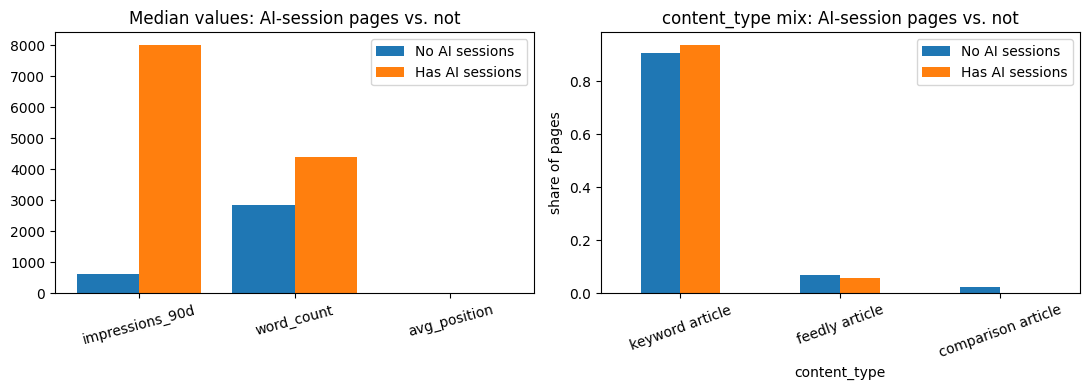

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Chart 1: median comparison bars
metrics = ["impressions_90d", "word_count", "avg_position"]
no_ai_vals = [df[~has_ai_sessions][m].median() for m in metrics]
has_ai_vals = [df[has_ai_sessions][m].median() for m in metrics]

x = range(len(metrics))
axes[0].bar([i - 0.2 for i in x], no_ai_vals, width=0.4, label="No AI sessions")
axes[0].bar([i + 0.2 for i in x], has_ai_vals, width=0.4, label="Has AI sessions")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(["impressions_90d", "word_count", "avg_position"], rotation=15)
axes[0].set_title("Median values: AI-session pages vs. not")
axes[0].legend()

# Chart 2: content_type mix comparison
ct_compare = pd.DataFrame({
    "No AI sessions": df[~has_ai_sessions]["content_type"].value_counts(normalize=True),
    "Has AI sessions": df[has_ai_sessions]["content_type"].value_counts(normalize=True),
}).fillna(0)
ct_compare.plot(kind="bar", ax=axes[1])
axes[1].set_title("content_type mix: AI-session pages vs. not")
axes[1].set_ylabel("share of pages")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 4. Careful words: what I can and can't claim

*Write what your work will be able to say (observed, directional, decision-support) — and what it never will (causal proof, 'predicting Google').*

What I can claim:

What fraction of pages show observed AI-referral session activity, and how that compares across content characteristics (word count, impressions, position, content type) — these are direct measurements from the data.
Directional associations — "pages with AI sessions tend to have higher search impressions and longer content" — described as observed patterns, not causes.
Ranked opportunity lists: pages that look similar to AI-session pages on observable traits but currently show none, framed as candidates for human review, not guaranteed wins.

What I can't claim:

That any specific structural feature (word count, FAQ blocks, definitions, etc.) causes AI referral traffic. The data shows correlation between traits at best — proving causation would require a controlled experiment (e.g., restructuring a page and measuring before/after AI sessions), which is outside the scope of this data.
Anything about AI ranking, AI citation behavior, or how AI models actually parse or select content. ai_sessions_90d / sessions_ai only measures sessions where a person already clicked through from an AI tool — it says nothing about visibility, ranking, or citation frequency inside the AI tool itself, only about the outcome after the click.
That "zero AI sessions" means a page is invisible to AI tools. With only 1,930 positive rows out of 30,000, absence of a session in this window could just as easily be normal sparsity as a real signal — I can't tell the difference without a much larger sample or a longer window.
Any claim tied to a specific client, domain, URL, or query — the data is pseudonymized and I won't attempt to reverse that.

I'm treating this lane as exploratory pattern-finding in service of a ranked opportunity list, not as a predictive or causal model — consistent with the lane guide's explicit warning against training a classifier on data this sparse.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.